In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import cross_val_score

In [3]:
df = pd.read_csv("boston.csv")

In [4]:
df = df.drop(columns=['Unnamed: 0'])

In [5]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
df.shape

(506, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [8]:
# Seperate Featues(X) and Target (y)
X = df.drop("medv",axis = 1) # featues
y = df["medv"] # target

In [9]:
X.shape,y.shape

((506, 13), (506,))

In [10]:
# train test split
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Train data -> learn patterns
# Test data -> check generalization

In [11]:
# Create & Train Linear regresssion Model 
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
mse = cross_val_score(model,X_train,y_train,scoring="neg_mean_squared_error",cv=5)

In [13]:
np.mean(mse)

np.float64(-23.654418270304625)

In [15]:
# make predication 
y_pred = model.predict(X_test)

In [16]:
# Evaluate the Model 
# MSE
mse = mean_squared_error(y_test,y_pred)
print("MSE: ",mse)

MSE:  24.291119474973538


In [17]:
# R2 Score -> accuracy
r2 = r2_score(y_test,y_pred)
print("R2 : ",r2)

R2 :  0.6687594935356317


In [18]:
# Model Coefficients 
coeff_df = pd.DataFrame({
    "Features":X.columns,
    "Coefficient":model.coef_
})
coeff_df.sort_values(by="Coefficient",ascending = False)

,Features,Coefficient
5,rm,4.438835
3,chas,2.784438
8,rad,0.262430
2,indus,0.040381
1,zn,0.030110
11,black,0.012351
6,age,-0.006296
9,tax,-0.010647
0,crim,-0.113056
12,lstat,-0.508571


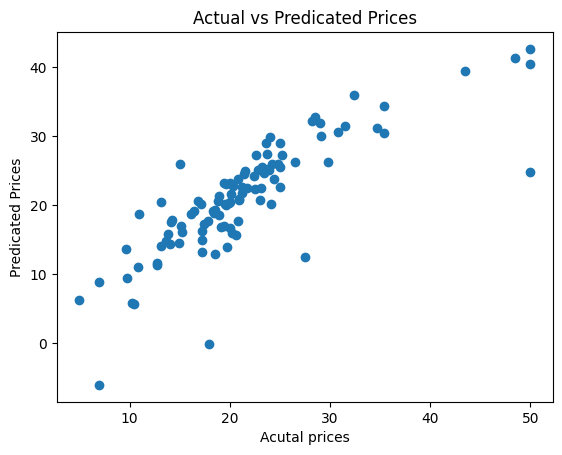

In [19]:
# visualization predication 
plt.scatter(y_test,y_pred)
plt.xlabel("Acutal prices")
plt.ylabel("Predicated Prices")
plt.title("Actual vs Predicated Prices")
plt.show()

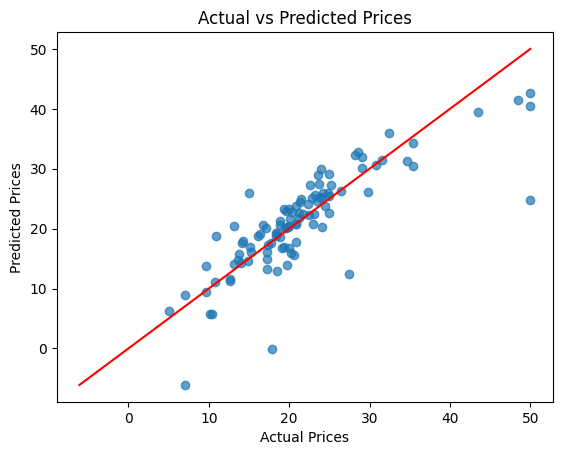

In [20]:
plt.scatter(y_test,y_pred,alpha = 0.7)
min_val = min(y_test.min(),y_pred.min())
max_val = max(y_test.max(),y_pred.max())
plt.plot([min_val,max_val],[min_val,max_val],color = "red")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

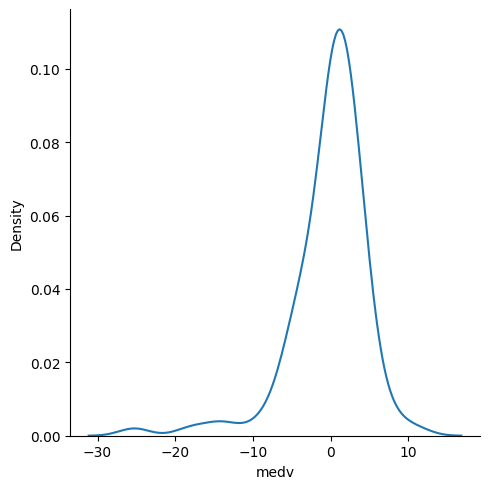

In [31]:
sns.displot(y_pred - y_test,kind="kde")
plt.show()

# Ridge and Lasso Linear Regression 

In [21]:
r2 

0.6687594935356317

In [22]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [23]:
ridge_regressor = Ridge()

In [24]:
ridge_regressor

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [25]:
parameters = {
    "alpha":[1,2,5,10,20,40,50,60,70,80,90]
}
ridgecv = GridSearchCV(ridge_regressor,parameters,scoring="neg_mean_squared_error",cv=5,)
ridgecv.fit(X_train,y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [1, 2, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1


In [26]:
# check the which paramter is best perform 
print(ridgecv.best_params_)

{'alpha': 1}


In [27]:
print(ridgecv.best_score_)

-23.96555607592505


In [29]:
ridge_pred = ridgecv.predict(X_test)

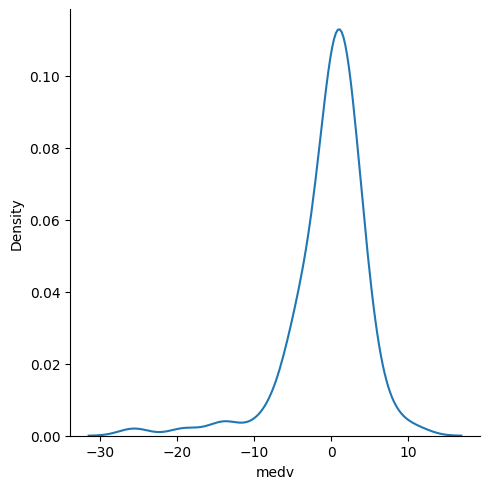

In [32]:
sns.displot(ridge_pred - y_test,kind="kde")
plt.show()

In [33]:
ridgemse = mean_squared_error(ridge_pred,y_test)
print("MSE: ",mse)

MSE:  24.291119474973538


In [34]:
ridgeR2 = r2_score(ridge_pred,y_test)
print("R2 : ",ridgeR2)

R2 :  0.6316692350060944


## Lasso Regression 

In [35]:
from sklearn.linear_model import Lasso

In [36]:
lasso = Lasso()

In [37]:
parameters = {
    "alpha":[1,2,5,10,20,40,50,60,70,80,90]
}
lassocv = GridSearchCV(lasso,parameters,scoring="neg_mean_squared_error",cv=5,)
lassocv.fit(X_train,y_train)

,estimator,Lasso()
,param_grid,"{'alpha': [1, 2, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1


In [38]:
print(lassocv.best_params_)

{'alpha': 1}


In [39]:
print(lassocv.best_score_)

-28.13462403557163


In [40]:
lasso_pred = lassocv.predict(X_test)

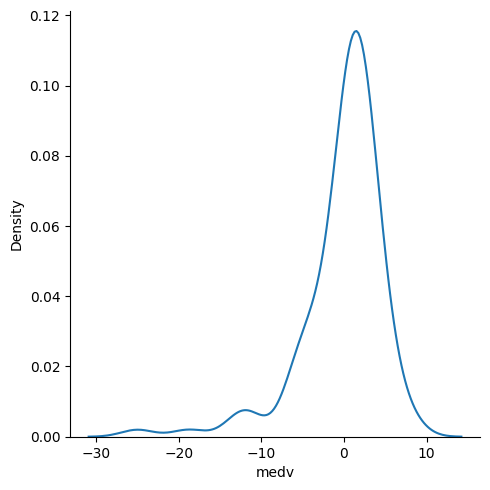

In [41]:
sns.displot(lasso_pred-y_test,kind = "kde")